In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib as m
from tqdm import tqdm
from scipy import linalg
import scipy as sp
import os
import pickle
import glob
import h5py
import random

from scipy.constants import *

phi0 = physical_constants["mag. flux quantum"][0]
eps0 = epsilon_0

from scipy.special import eval_hermite
import scfitpy as Qfit

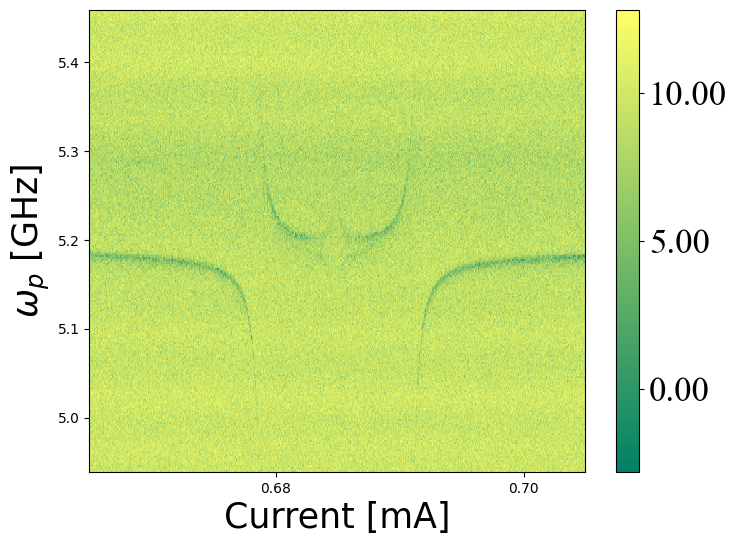

In [3]:
# Load test spectrum
_dat = np.load("./assets/cwSpec_currentSweep_202407011423.npz")
current = _dat["current"]  # mA
freq = _dat["freq"]  # GHz

mag1 = _dat["mag1"]  # 2d-spectrum date, dims=[freq, current]

fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams["font.size"] = 25
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

X, Y = np.meshgrid(freq, current)
mappable = ax.pcolor(Y, X, mag1, cmap="summer")
cbar_num_format = "%.2f"
cbar = plt.colorbar(mappable, ax=ax, format=cbar_num_format)

plt.xlabel(r"Current [mA]", fontsize=25)
plt.ylabel(r"$\omega_p\ $[GHz]", fontsize=25)
plt.show()

In [ ]:
params0 = [2.78, 2.88, 5.00, 1.748, 0.659, 1.62]
Ej = params0[0] * 1e2
Ec = params0[1]
Lr = params0[2] * 1e-9
Cr = params0[3] * 1e-13
params = [Ej, Ec, Lr, Cr, params0[4], params0[5]]

pst = 21
phi_list0 = np.linspace(0.5, 0.51, pst)
nlist = [9, 6, 7]
E0, eps0 = Qfit.circuit_spectrum_gpu(phi_list0, params, nlist)

In [ ]:
f = open("PT_paper01.pickle", "rb")
Rabi_params = pickle.load(f)
f2 = 684.4 * 1e-3
f3 = -539.4 * 1e-3
df = f2 - f3

e2 = Qfit.Rabi05(phi_list0, Rabi_params, df)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
plt.rcParams["font.size"] = 19
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

ax.plot(phi_list0, np.array(e2[1]) - np.array(e2[0]), "-", color="b", label="10")
ax.plot(phi_list0, np.array(e2[2]) - np.array(e2[0]), "-", color="red", label="20")
ax.plot(phi_list0, np.array(e2[3]) - np.array(e2[1]), "-", color="green", label="31")

ax.plot(phi_list0, np.array(E0[1]) - np.array(E0[0]), "-.", color="b", label="10")
ax.plot(phi_list0, np.array(E0[2]) - np.array(E0[0]), "-.", color="red", label="20")
ax.plot(phi_list0, np.array(E0[3]) - np.array(E0[1]), "-.", color="green", label="31")

ax.set_ylim([5, 5.4])
plt.grid()
plt.xlabel(r"$\varphi_{ex}/2\pi$[a.u.]", fontsize=24)
plt.ylabel(r"$E/h\ $[GHz]", fontsize=22)
plt.legend(loc="lower left", ncol=1)
plt.show()
print(min(np.array(E0[1]) - np.array(E0[0])))
print(min(np.array(e2[1]) - np.array(e2[0])))

In [ ]:
pst = 31
phi_liste = np.linspace(0.5, 0.51, pst)
e2 = Qfit.Rabi05(phi_liste, Rabi_params, df)
e10 = np.array(e2[1]) - np.array(e2[0])
e20 = np.array(e2[2]) - np.array(e2[0])
e31 = np.array(e2[3]) - np.array(e2[1])


def err(e_params):
    Ej = e_params[0] * 1e2
    Ec = e_params[1]
    Lr = e_params[2] * 1e-9
    Cr = e_params[3] * 1e-13
    alpha = e_params[4]
    beta = e_params[5]
    e_params0 = [Ej, Ec, Lr, Cr, alpha, beta]
    err = []
    fu = 5.4
    fd = 5.0
    Ee, epse = Qfit.circuit_spectrum_gpu(phi_liste, e_params0, nlist)
    for i in range(len(e10)):
        ere1 = e10[i] - Ee[1][i] + Ee[0][i]
        if fu > e10[i] > fd:
            err.append(ere1)
    for i in range(len(e10)):
        ere2 = e20[i] - Ee[2][i] + Ee[0][i]
        if fu > e20[i] > fd:
            err.append(ere2)
    for i in range(len(e10)):
        ere3 = e31[i] - Ee[3][i] + Ee[1][i]
        if fu > e31[i] > fd:
            err.append(ere3)

    return abs(np.array(err)) * 10


print(sum(err(params0)))

In [ ]:
import time
from scipy.optimize import least_squares

start = time.time()

fitparams = least_squares(
    err, params0, jac="3-point"
)  # ,bounds=[[1.9, 2.0, 1.0 ,3.0, 0.65, 1.3, 0.9],[2.2, 3.5, 3.0, 6.0, 0.9, 3.0, 1.2]])

elapsed_time = time.time() - start
print("elapsed_time:{0}".format(elapsed_time / 60) + "[min]")

with open("4JJUS_PT3_1.pickle", mode="wb") as fo:
    pickle.dump(fitparams.x, fo)

In [ ]:
# f = open('PTpaper_circuit01.pickle','rb')#fitUSCSc2
f = open("4JJUS_PT3_1.pickle", "rb")  # fitUSCSc2
fitparams = pickle.load(f)
print(fitparams)
print(sum(err(fitparams)))
Ej = fitparams[0] * 1e2
Ec = fitparams[1]
Lr = fitparams[2] * 1e-9
Cr = fitparams[3] * 1e-13
fparams = [Ej, Ec, Lr, Cr, fitparams[4], fitparams[5]]

In [ ]:
phi_list0 = np.linspace(0.49, 0.51, 201)
E, eps = Qfit.circuit_spectrum_gpu(phi_list0, fparams, nlist)

In [ ]:
e3 = Qfit.Rabi05(phi_list0, Rabi_params, df)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
plt.rcParams["font.size"] = 19
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

ax.plot(phi_list0, np.array(e3[1]) - np.array(e3[0]), "-", color="g", label="Rabi")
ax.plot(phi_list0, np.array(e3[2]) - np.array(e3[0]), "-", color="b", label="")
ax.plot(phi_list0, np.array(e3[3]) - np.array(e3[1]), "-", color="r", label="")

ax.plot(phi_list0, np.array(E[1]) - np.array(E[0]), "-.", color="g", label="Circuit")
ax.plot(phi_list0, np.array(E[2]) - np.array(E[0]), "-.", color="b", label="")
ax.plot(phi_list0, np.array(E[3]) - np.array(E[1]), "-.", color="r", label="")

ax.set_ylim([5, 5.4])
plt.grid()
plt.xlabel(r"$\varphi_{ex}/2\pi$[a.u.]", fontsize=24)
plt.ylabel(r"$E/h\ $[GHz]", fontsize=22)
plt.legend(loc="lower left", ncol=1)
plt.show()
print(min(np.array(E[1]) - np.array(E[0])))
print(min(np.array(e3[1]) - np.array(e3[0])))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams["font.size"] = 25
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

X, Y = np.meshgrid(freq, (current - Rabi_params[6]) * Rabi_params[5])
mappable = ax.pcolor(Y, X, Qfit.normalization(mag1), cmap="summer")
cbar_num_format = "%.2f"
cbar = plt.colorbar(mappable, ax=ax, format=cbar_num_format)

ax.plot(eps, np.array(E[1]) - np.array(E[0]), "-.", color="b", label="$\\omega_{10}$")
ax.plot(eps, np.array(E[2]) - np.array(E[0]), "-.", color="r", label="$\\omega_{20}$")
ax.plot(eps, np.array(E[3]) - np.array(E[1]), "-.", color="g", label="$\\omega_{31}$")

ax.set_ylim([min(freq), max(freq)])
ax.set_xlim([-15, 15])
plt.xlabel(r"$\varepsilon$ [GHz]", fontsize=25)
plt.ylabel(r"$\omega_p $[GHz]", fontsize=25)
plt.legend(
    loc="upper left",
    borderaxespad=0,
    labelspacing=0.2,
    ncol=1,
    labelcolor="black",
    facecolor="whitesmoke",
    framealpha=0.5,
)
plt.savefig("CircFitPT.png", bbox_inches="tight", pad_inches=0.5, dpi=700)
plt.show()